In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [24]:
dados_caminho = "../dados/dados_nao_processados/"

arquivos_csv = [f for f in os.listdir(dados_caminho) if f.endswith('.csv')]

dataframes = []
for arquivo in arquivos_csv:
    print(f"Carregando: {arquivo}...")
    df = pd.read_csv(
        os.path.join(dados_caminho, arquivo),
        encoding='utf-8',
        low_memory=False
    )
    dataframes.append(df)
    print(f"  → {df.shape[0]} registros carregados")

df_total = pd.concat(dataframes, ignore_index=True)

print(f"\n✅ Dataset unificado!")
print(f"📊 Registros: {df_total.shape[0]:,}")
print(f"📋 Colunas:   {df_total.shape[1]}")


Carregando: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
  → 225745 registros carregados
Carregando: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  → 286467 registros carregados
Carregando: Friday-WorkingHours-Morning.pcap_ISCX.csv...
  → 191033 registros carregados
Carregando: Monday-WorkingHours.pcap_ISCX.csv...
  → 529918 registros carregados
Carregando: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
  → 288602 registros carregados
Carregando: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
  → 170366 registros carregados
Carregando: Tuesday-WorkingHours.pcap_ISCX.csv...
  → 445909 registros carregados
Carregando: Wednesday-workingHours.pcap_ISCX.csv...
  → 692703 registros carregados

✅ Dataset unificado!
📊 Registros: 2,830,743
📋 Colunas:   79


In [25]:
print("=== TIPOS DE DADOS ===\n")
print(df_total.dtypes)
print(f"\n=== RESUMO ===")
print(f"Colunas numéricas:    {df_total.select_dtypes(include=[np.number]).shape[1]}")
print(f"Colunas não-numéricas: {df_total.select_dtypes(exclude=[np.number]).shape[1]}")


=== TIPOS DE DADOS ===

 Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
 Label                             str
Length: 79, dtype: object

=== RESUMO ===
Colunas numéricas:    78
Colunas não-numéricas: 1


In [26]:
print("=== ESTATÍSTICAS DESCRITIVAS ===\n")
df_total.describe().T


=== ESTATÍSTICAS DESCRITIVAS ===



C:\Users\William\AppData\Roaming\Python\Python314\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\William\AppData\Roaming\Python\Python314\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


In [27]:
nulos = df_total.isnull().sum()
nulos_percentual = (nulos / len(df_total)) * 100

nulos_df = pd.DataFrame({
    'Quantidade': nulos,
    'Percentual (%)': nulos_percentual.round(2)
})

# Mostrar apenas colunas que têm nulos
nulos_com_problema = nulos_df[nulos_df['Quantidade'] > 0]

if len(nulos_com_problema) > 0:
    print("⚠️ COLUNAS COM VALORES NULOS:\n")
    print(nulos_com_problema)
else:
    print("✅ Nenhuma coluna com valores nulos!")

print(f"\n📊 Total de valores nulos no dataset: {df_total.isnull().sum().sum():,}")


⚠️ COLUNAS COM VALORES NULOS:

              Quantidade  Percentual (%)
Flow Bytes/s        1358            0.05

📊 Total de valores nulos no dataset: 1,358


In [28]:
colunas_numericas = df_total.select_dtypes(include=[np.number]).columns

infinitos = np.isinf(df_total[colunas_numericas]).sum()
infinitos_com_problema = infinitos[infinitos > 0]

if len(infinitos_com_problema) > 0:
    print("⚠️ COLUNAS COM VALORES INFINITOS:\n")
    print(infinitos_com_problema)
else:
    print("✅ Nenhuma coluna com valores infinitos!")

print(f"\n📊 Total de valores infinitos: {np.isinf(df_total[colunas_numericas]).sum().sum():,}")


⚠️ COLUNAS COM VALORES INFINITOS:

Flow Bytes/s       1509
 Flow Packets/s    2867
dtype: int64

📊 Total de valores infinitos: 4,376


In [29]:
duplicados = df_total.duplicated().sum()
percentual_dup = (duplicados / len(df_total)) * 100

print(f"📊 Registros duplicados: {duplicados:,} ({percentual_dup:.2f}%)")


📊 Registros duplicados: 308,381 (10.89%)


In [30]:
distribuicao = df_total[' Label'].value_counts()
distribuicao_pct = df_total[' Label'].value_counts(normalize=True) * 100

tabela_classes = pd.DataFrame({
    'Quantidade': distribuicao,
    'Percentual (%)': distribuicao_pct.round(2)
})

print("=== DISTRIBUIÇÃO DAS CLASSES ===\n")
print(tabela_classes)
print(f"\n📊 Total de classes: {df_total[' Label'].nunique()}")


=== DISTRIBUIÇÃO DAS CLASSES ===

                            Quantidade  Percentual (%)
 Label                                                
BENIGN                         2273097           80.30
DoS Hulk                        231073            8.16
PortScan                        158930            5.61
DDoS                            128027            4.52
DoS GoldenEye                    10293            0.36
FTP-Patator                       7938            0.28
SSH-Patator                       5897            0.21
DoS slowloris                     5796            0.20
DoS Slowhttptest                  5499            0.19
Bot                               1966            0.07
Web Attack � Brute Force          1507            0.05
Web Attack � XSS                   652            0.02
Infiltration                        36            0.00
Web Attack � Sql Injection          21            0.00
Heartbleed                          11            0.00

📊 Total de classes: 15


C:\Users\William\AppData\Local\Temp\ipykernel_5616\427355842.py:23: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\William\AppData\Local\Temp\ipykernel_5616\427355842.py:24: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig("../resultados/graficos/distribuicao_classes.png", dpi=300, bbox_inches='tight')
C:\Users\William\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


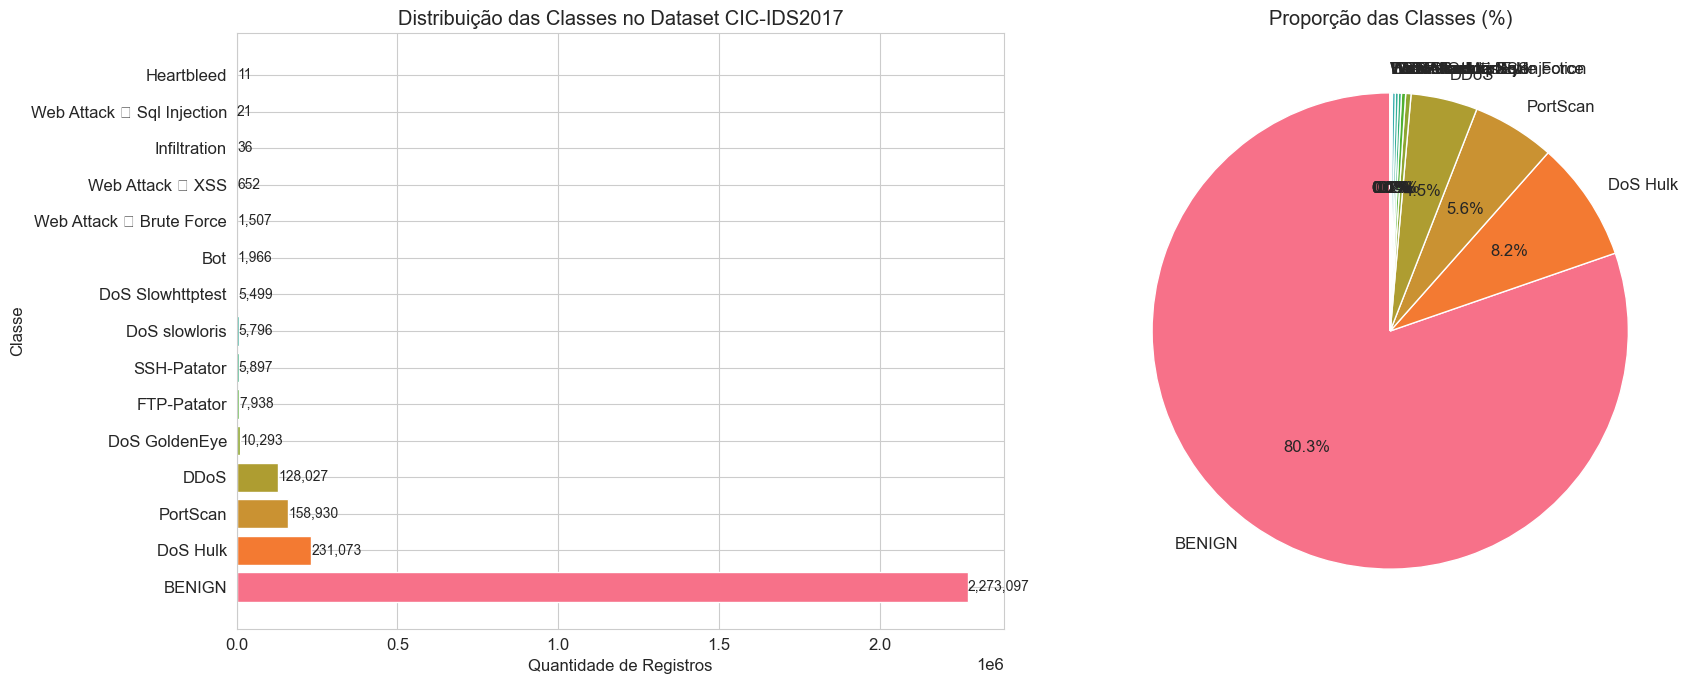

✅ Gráfico salvo em: resultados/graficos/distribuicao_classes.png


In [31]:
# Criar pasta de resultados se não existir
os.makedirs("../resultados/graficos", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de barras
cores = sns.color_palette("husl", n_colors=len(distribuicao))
bars = axes[0].barh(distribuicao.index, distribuicao.values, color=cores)
axes[0].set_xlabel("Quantidade de Registros")
axes[0].set_ylabel("Classe")
axes[0].set_title("Distribuição das Classes no Dataset CIC-IDS2017")

# Adicionar valores nas barras
for bar, valor in zip(bars, distribuicao.values):
    axes[0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                 f'{valor:,}', va='center', fontsize=10)

# Gráfico de pizza
axes[1].pie(distribuicao.values, labels=distribuicao.index, autopct='%1.1f%%',
            colors=cores, startangle=90)
axes[1].set_title("Proporção das Classes (%)")

plt.tight_layout()
plt.savefig("../resultados/graficos/distribuicao_classes.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em: resultados/graficos/distribuicao_classes.png")


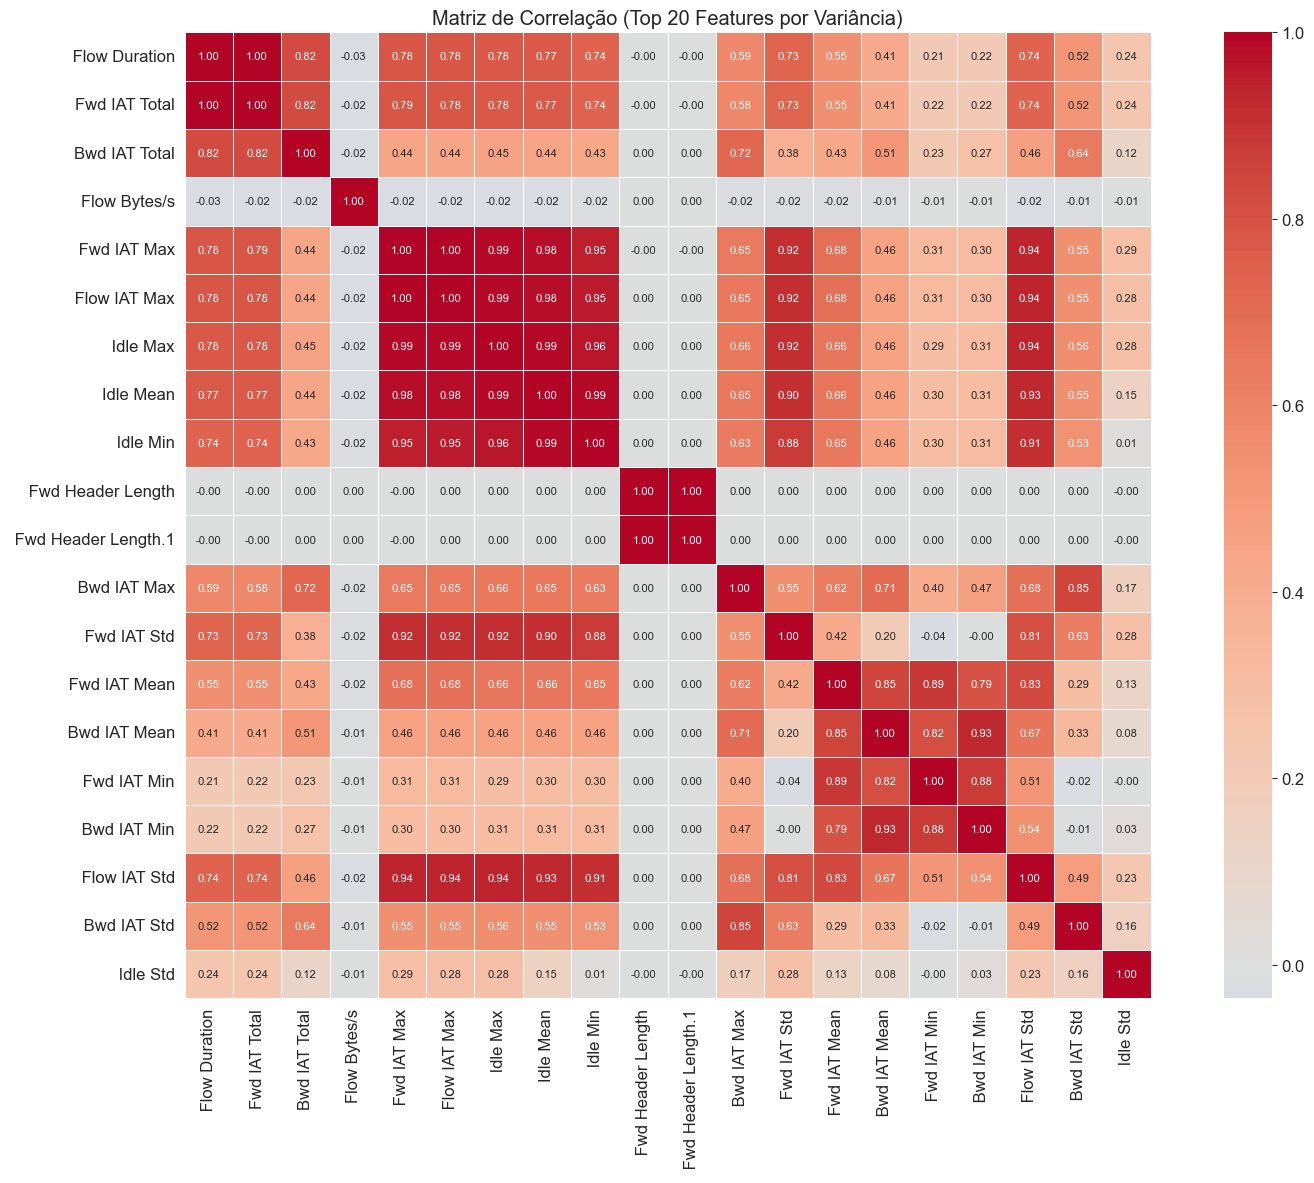

✅ Gráfico salvo em: resultados/graficos/matriz_correlacao.png


In [32]:
# Selecionar apenas colunas numéricas
df_numerico = df_total.select_dtypes(include=[np.number])

# Substituir infinitos por NaN temporariamente para calcular correlação
df_numerico = df_numerico.replace([np.inf, -np.inf], np.nan)

# Calcular a correlação e pegar as 20 features com maior variância
top_features = df_numerico.var().nlargest(20).index
correlacao = df_numerico[top_features].corr()

# Plotar
plt.figure(figsize=(16, 12))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title("Matriz de Correlação (Top 20 Features por Variância)")
plt.tight_layout()
plt.savefig("../resultados/graficos/matriz_correlacao.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em: resultados/graficos/matriz_correlacao.png")


In [33]:
print("=" * 60)
print("          RESUMO DA ANÁLISE EXPLORATÓRIA")
print("=" * 60)
print(f"\n📊 Total de registros:          {df_total.shape[0]:,}")
print(f"📋 Total de colunas:            {df_total.shape[1]}")
print(f"🔢 Colunas numéricas:           {df_total.select_dtypes(include=[np.number]).shape[1]}")
print(f"📝 Colunas não-numéricas:       {df_total.select_dtypes(exclude=[np.number]).shape[1]}")
print(f"❌ Total de valores nulos:      {df_total.isnull().sum().sum():,}")
print(f"♾️  Total de valores infinitos:  {np.isinf(df_total.select_dtypes(include=[np.number])).sum().sum():,}")
print(f"📑 Registros duplicados:        {duplicados:,}")
print(f"🏷️  Total de classes:            {df_total[' Label'].nunique()}")
print(f"\n{'=' * 60}")
print("DISTRIBUIÇÃO DAS CLASSES:")
print("=" * 60)
for label, count in distribuicao.items():
    pct = (count / len(df_total)) * 100
    print(f"  {label:30s} → {count:>10,} ({pct:.2f}%)")
print("=" * 60)


          RESUMO DA ANÁLISE EXPLORATÓRIA

📊 Total de registros:          2,830,743
📋 Total de colunas:            79
🔢 Colunas numéricas:           78
📝 Colunas não-numéricas:       1
❌ Total de valores nulos:      1,358
♾️  Total de valores infinitos:  4,376
📑 Registros duplicados:        308,381
🏷️  Total de classes:            15

DISTRIBUIÇÃO DAS CLASSES:
  BENIGN                         →  2,273,097 (80.30%)
  DoS Hulk                       →    231,073 (8.16%)
  PortScan                       →    158,930 (5.61%)
  DDoS                           →    128,027 (4.52%)
  DoS GoldenEye                  →     10,293 (0.36%)
  FTP-Patator                    →      7,938 (0.28%)
  SSH-Patator                    →      5,897 (0.21%)
  DoS slowloris                  →      5,796 (0.20%)
  DoS Slowhttptest               →      5,499 (0.19%)
  Bot                            →      1,966 (0.07%)
  Web Attack � Brute Force       →      1,507 (0.05%)
  Web Attack � XSS               →        6